# 12. Γεωεπεξεργασία ψηφιδωτών δεδομένων (rasterio)

Η βιβλιοθήκη [Rasterio](https://rasterio.readthedocs.io/en/stable/) αποτελεί μια από τις πιο διαδεδομένες βιβλιοθήκες για την ανάγνωση και εγγραφή ψηφιδωτών αρχείων (raster).
Είναι δομημένη πάνω στην βιβλιοθήκη GDAL (Geospatial Data Abstraction Library) και παρέχει πιο εύχρηστο τρόπο συγγραφής κώδικα στα πρότυπα που απαιτεί η Python (pythonic).

Ως προς τις δυνατότητες παρέχει ανάγνωση και εγγραφή ψηφιδωτών αρχείων, πρόσβαση στα μεταδεδομένα και τις ιδιότητές τους (πχ γεωγραφικό σύστημα αναφοράς, διακριτική ικανότητα, πρόσβαση σε πολλαπλά κανάλια εικόνας). Επιπλέον συνδυάζεται άριστα με την βιβλιοθήκη [numpy](https://numpy.org/) και είναι συμβατή με βιβλιοθήκες για αλληλεπίδραση με διανυσματικά δεδομένα ([Shapely](https://shapely.readthedocs.io/), [GeoPandas](https://geopandas.org/), and [PyProj](https://pyproj4.github.io/pyproj/stable/)) ενώ μέσω της βιβλιοθήκης [matplotlib](https://matplotlib.org/) δίνει την δυνατότητα οπτικοποίησης ψηφιδωτών δεδομένων. Ταυτόχρονα ένα από τα πλεονεκτήματά της είναι η δυνατότητα ανάγνωσης μεγάλων δεδομένων (block wise reading).


## Εγκατάσταση της βιβλιοθήκης, βασικές λειτουργίες
Η εγκατάσταση της βιβλιοθήκης `rasterio` εξαρτάται από το περιβάλλον εργασίας. Σε περίπτωση που το περιβάλλον εργασίας είναι το `conda` τότε η εγκατάσταση της `rasterio` από το κανάλι `conda-forge` γίνεται με την εντολή  `conda install -c conda-forge rasterio`. Για το `pip` χρησιμοποιείται η εντολή `pip install rasterio`. Περισσότερες λεπτομέρειες για την εγκατάσταση της βιβλιοθήκης αναφέρονται εδώ: https://rasterio.readthedocs.io/en/stable/installation.html

## Εισαγωγή βιβλιοθηκών

In [1]:
import rasterio # βιβλιοθήκη για την ανάγνωση, επεξεργασία και εγγραφή διανυσματικών δεδομένων
from rasterio.plot import show,show_hist # υπορουτίνες την rasterio για την οπτικοποίηση ψηφιδωτών (raster) δεδομένων και ιστογραμμάτων
from matplotlib import pyplot as plt # βιβλιοθήκη για την οπτικοποίηση δεδομένων  σε διαγράμματα
import numpy as np

## Άνοιγμα αρχείου
Για το άνοιγμα ενός ψηφιδωτού αρχείου χρησιμοποιείται η μέθοδος `open` από την βιβλιοθήκη `rasterio`. Στην συνέχεια, στο object του αρχείου που έχει ανοίξει καλούμε την μέθοδο `read` η οποία διαβάζει τις τιμές των pixel από όλα τα κανάλια (bands) της εικόνας (ή από επιλεγμένα αν οριστεί index) και τα επισυνάπτει σε ένα numpy array. Η μέθοδος `read`, εκτός των άλλων, δέχεται σαν παράμετρο είτε τον index του καναλίου που θέλουμε να ανοίξουμε είτε τίποτα οπότε και θα διαβάσει όλα τα κανάλια. Αξίζει να σημειωθεί ότι στο `rasterio` το index για το πρώτο κανάλι είναι το `1` και όχι το `0` όπως συνηθίζεται στην Python.  Ωστόσο η μέθοδος `read` επιστρέφει ένα numpy array 3 διαστάσεων της μορφής (band,row,column), τα index του οποίου, σαν τυπικό numpy ndarray, αρχίζουν από το `0` (zero based). Στο παρακάτω παράδειγμα χρησιμοποιείται η  `rasterio` για την ανάγνωση όλων των καναλιών μιας εικόνας LandSat8 σαν numpy array. 

In [2]:
# Source: Landsat 8-9 OLI/TIRS Collection 2 Level-2 Science Products 
# https://www.usgs.gov/centers/eros/science/usgs-eros-archive-landsat-archives-landsat-8-9-olitirs-collection-2-level-2
path = 'LC08_L2SP_183033_20250906_20250912_02_T1_SR_VOLOS.tif'

with rasterio.open(path) as src:
    data = src.read() # ανάγνωση όλων των καναλιών, επιστρέφει numpy ndarray
    print(data.shape)

(7, 238, 287)


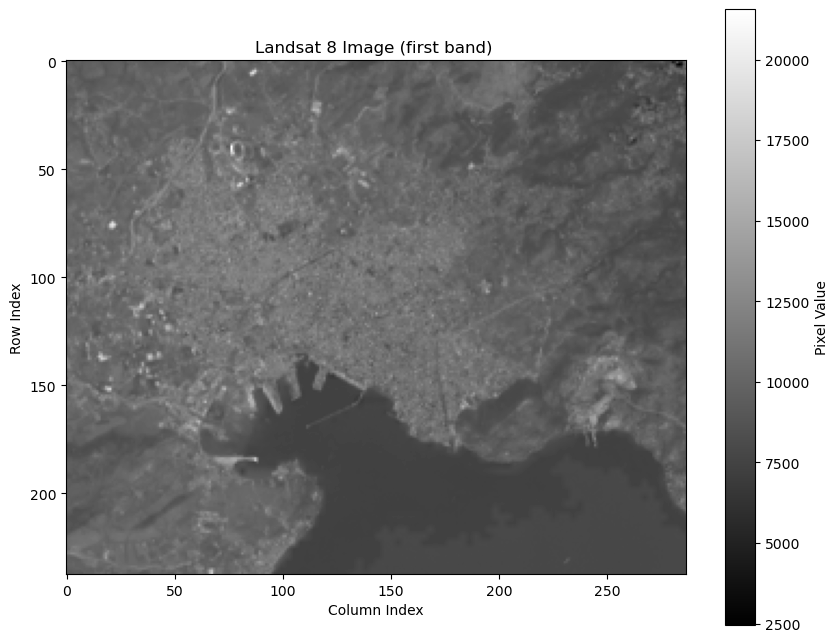

In [3]:
# Οπτικοποίηση του 'data' array, first band
band_index= 0

plt.figure(figsize=(10, 8))
img = plt.imshow(data[band_index,::], cmap=plt.cm.gray )  # 'viridis': χρωματική παλέτα για συνεχή δεδομένα
plt.colorbar(img, label='Pixel Value') # υπόμνημα
plt.title("Landsat 8 Image (first band) ")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.show()

Επιπλέον, είναι δυνατή η ανάγνωση αρχείων geotiff που φιλοξενούνται διαδικτυακά ([Cloud Optimized GeoTIFF (COG)](https://cogeo.org/)). Ανεξάρτητα που είναι αποθηκευμένο το αρχείο προς ανάγνωση (τοπικά ή απομακρυσμένα) είναι δυνατόν κατά την ανάγνωση να οριστεί ένα τμήμα του αρχείου μόνο. Το τμήμα αυτό μπορεί να οριστεί με δύο τρόπους. Είτε να οριστεί ένα υποσύνολο δίνοντας σαν αρχικό σημείο κατάτμησης το index του πάνω αριστερά pixel ενός bounding box και στην συνέχεια το πλάτος και το ύψος του πάλι σε pixels. Στο παρακάτω παράδειγμα, και σε ένα υποθετικό raster διαστάσεων 100x100 ορίζεται μια περιοχή κατάτμησης ξεκινώντας από το σημείο (20,20) με πλάτος 50 pixels και ύψος 40 pixels.


<img src="raster_clip.svg" alt="drawing" style="width:400px;"/>

Ακολουθεί το παρακάτω παράδειγμα με την χρήση της συνάρτησης `Window` από το submodule `windows` του πακέτου `rasterio`. Γίνεται ανάγνωση τμήματος του αρχείου μέσω της ορισμού window (pixel έναρξης μέσω του ορισμού row_start και col_start και του width και height σε pixels).


In [4]:
from rasterio.windows import Window

with rasterio.open(path) as src:
    # Pixel πάνω αριστερά στο bounding box
    row_start = 20
    col_start =30
    
    width  = 80
    height  = 80

    window = Window(
        col_off=col_start,
        row_off=row_start,
        width=width,
        height=height
    )

    clipped = src.read(1, window=window)

clipped.shape

(80, 80)

Το object `data` είναι ένα τυπικό numpy ndarray το οπoίο μπορεί να οπτικοποιηθεί με την βοήθεια της βιβλιοθήκης `matplotlib`.

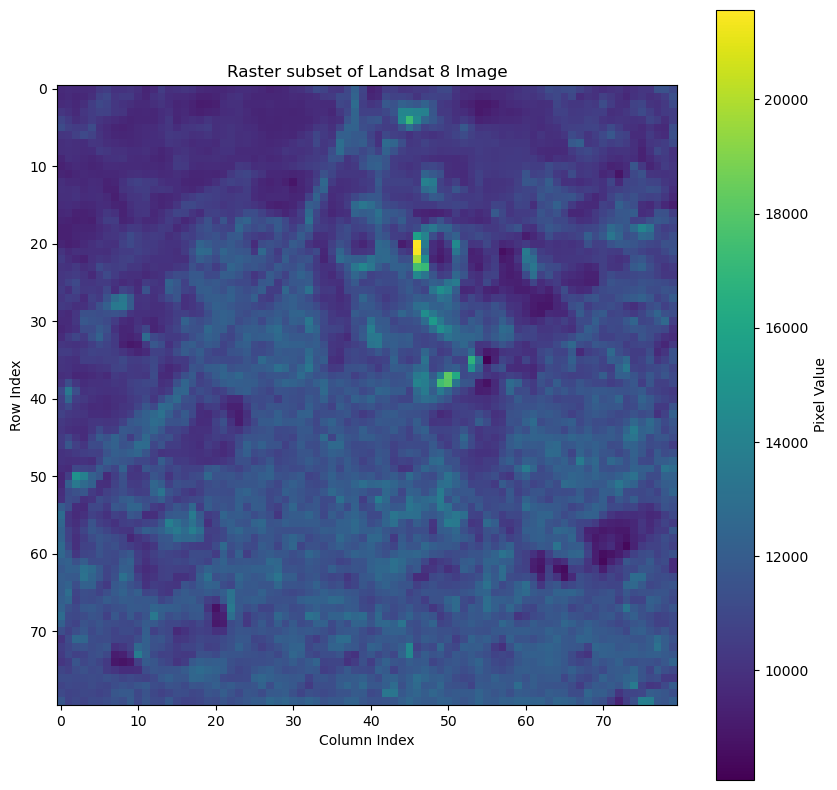

In [5]:
# Οπτικοποίηση του 'data' array
plt.figure(figsize=(10, 10))
img = plt.imshow(clipped, cmap='viridis')  # 'viridis': χρωματική παλέτα για συνεχή δεδομένα
plt.colorbar(img, label='Pixel Value') # υπόμνημα
plt.title("Raster subset of Landsat 8 Image")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.show()

Επίσης μπορούμε να αποκόψουμε ένα raster ορίζοντας τις συντενταγμένες των ακραίων σημείων (στο προβολικό σύστημα του αρχείου) ενός bounding box που ενδιαφέρει τον χρήστη. Στο παρακάτω παράδειγμα δίνεται η ανάγνωση ενός αρχείου Cloud Optimized GeoTIFF (COG) μέσω του ορισμού bounding box σε γεωγραφικές συντεταγμένες αντίστοιχες με το προβολικό σύστημα του αρχείου προς ανάγνωση.

In [18]:
from rasterio.windows import from_bounds
url = 'https://huggingface.co/datasets/leoliakos/LandSat8/resolve/main/LC08_L2SP_183033_20250906_20250912_02_T1_SR.tif'

# Συντεταγμένες για τον Βόλο. Οι συντεταγμένες δίνονται στο προβολικό σύστημα της εικόνας προς ανάγνωση.
left   = 632003
bottom = 4315978
right  = 717315
top    = 4395603

# These settings are for cloud performance
env_options = {
    'GDAL_HTTP_MERGE_CONSECUTIVE_REPORTS': 'YES',
    'GDAL_HTTP_MULTIPLEX': 'YES',
    'GDAL_HTTP_VERSION': '2',
    'VSI_CACHE': 'YES',
    'VSI_CACHE_SIZE': '50000000', # 50MB cache
    'GDAL_DISABLE_READDIR_ON_OPEN': 'EMPTY_COLUMN',
}

with rasterio.Env(**env_options):

    with rasterio.open(url) as ds:
        window = from_bounds(
            left=left,
            bottom=bottom,
            right=right,
            top=top,
            transform=ds.transform
        )
        data1 = ds.read(1, window=window) # ανάγνωση πρώτης μπάντας και σε γεωγραφικό υποσύνολο της εικόνας

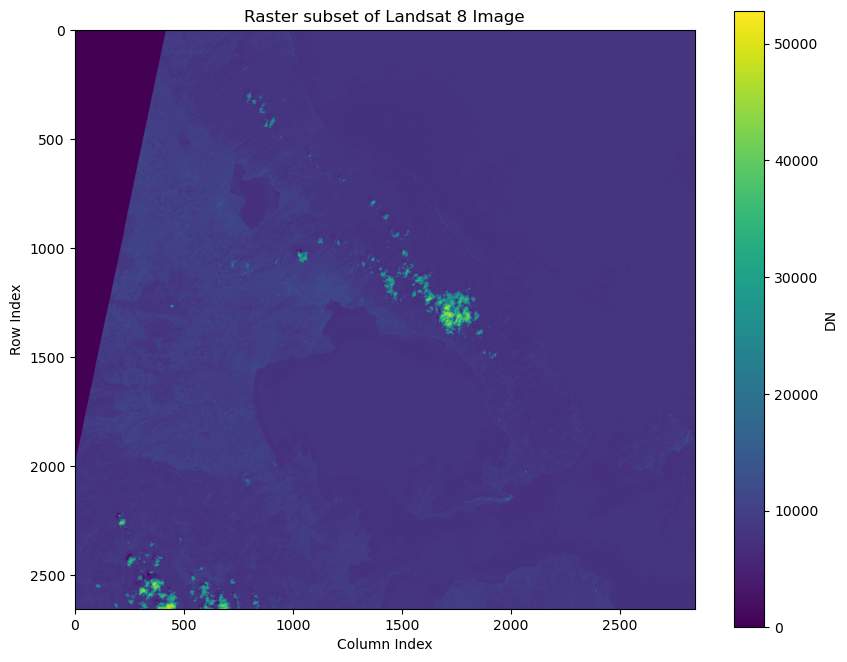

In [19]:
# Οπτικοποίηση του 'data' array
plt.figure(figsize=(10, 8))
img = plt.imshow(data1, cmap='viridis')  # 'viridis': χρωματική παλέτα για συνεχή δεδομένα
plt.colorbar(img, label='DN') # υπόμνημα
plt.title("Raster subset of Landsat 8 Image")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.show()

Όπως φαίνεται η οπτικοποίηση των δεδομένων μιας δορυφορικής εικόνας μέσω της `matplotlib` δεν ενδείκνυεται, δεδομένου ότι δεν υποστηρίζει την γεωγραφική πληροφορία, γι' αυτό και στους άξονες περιγράφονται μόνο η σειρά των ευρετηρίων των γραμμών και στηλών. Επιπλέον η σειρά των καναλιών της `rasterio` ακολουθεί την λογική (bands, rows, columns) κατά την ανάγνωση ενώ το `matplotlib` δέχεται numpy ndarrays της δομής (rows, columns, bands). Γι αυτό τον λόγο η `rasterio` προσφέρει την συνάρτηση `show` η οποία αποδίδει την γεωγραφική πληροφορία στους άξονες και αναμένει numpy arrays συμβατά με αυτά που επιστρέφει η `rasterio` κατά την ανάγνωση ψηφιδώτων δεδομένων.

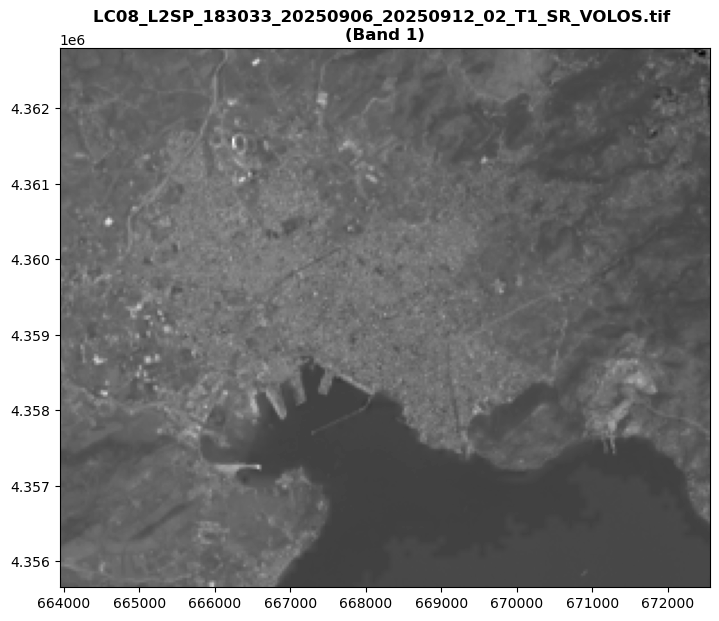

In [8]:
fig, ax = plt.subplots(1,1, figsize=(21,7))
band_id = 1
with rasterio.open(path) as src:
    map1 = show(src.read(band_id), 
                ax=ax,
                cmap=plt.cm.gray,  
                title=f'{path} \n(Band {band_id})',
                transform=src.transform)


## Δημιουργία εικόνας RGB

Πιο ρεαλιστική απεικόνιση της δορυφορικής εικόνας Landsat μπορούμε να λάβουμε μέσω της δημιουργίας RGB αναπαράστασης.
Στον LandSat 8 τα σχετικά κανάλια που ορίζουν το Red, Green, Blue είναι το 4, 3 και το 2 αντίστοιχα.

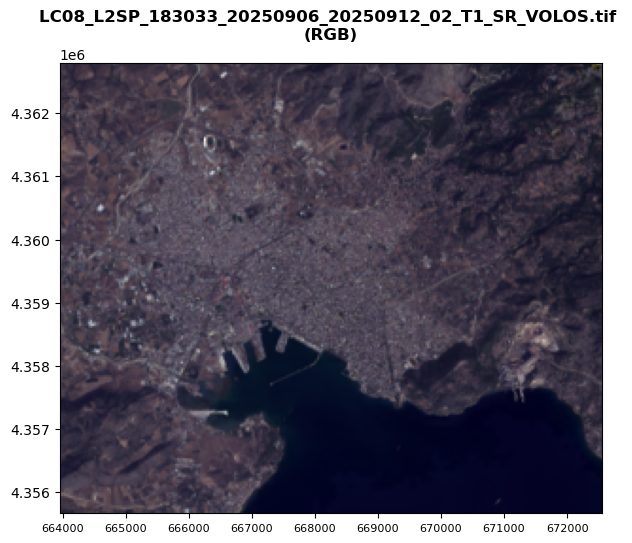

In [9]:
def normalize(band):
    band_min, band_max = (band.min(), band.max())
    return ((band-band_min)/((band_max - band_min)))


with rasterio.open(path) as src:
    image =src.read()
    bands = {src.descriptions[i]:image[i,:,:] for i in range(0,src.count)}
    transform = src.transform

# συγχώνευση συγκεκριμένων bands (numpy array) σε 3D array
rgb = np.dstack((normalize(bands['LC08_L2SP_183033_20250906_20250912_02_T1_SR_B4']), # RED 
                 normalize(bands['LC08_L2SP_183033_20250906_20250912_02_T1_SR_B3']), # GREEN
                  normalize(bands['LC08_L2SP_183033_20250906_20250912_02_T1_SR_B2'])) # BLUE
                  )
# το rgb.shape είναι (238, 287, 3) δηλ. [row, column, band]

rgb = np.rollaxis(rgb, axis=2) # αναταξινόμηση των διαστάσεων ως [band, row, col], απαιτούμενο για show function της rasterio

# Δημιουργία figure και axes
fig, ax = plt.subplots(figsize=(7, 7))
show(rgb ,title=f'{path} \n(RGB)', transform=transform,ax=ax)


from matplotlib.ticker import MultipleLocator # δίνει την δυνατότητα ορισμού του format και της θέσης των axis labels

# ορισμός x-axis tick interval σε 1000
ax.xaxis.set_major_locator(MultipleLocator(1000))

# ορισμός font size και rotation στα x-axis labels
plt.xticks(rotation=0, fontsize = 8)

plt.show()

Ενναλακτικά μπορούμε να οπτικοποιήσουμε άμεσα τις συγκεκριμένες μπάντες με την μέθοδο `show` της `rasterio`

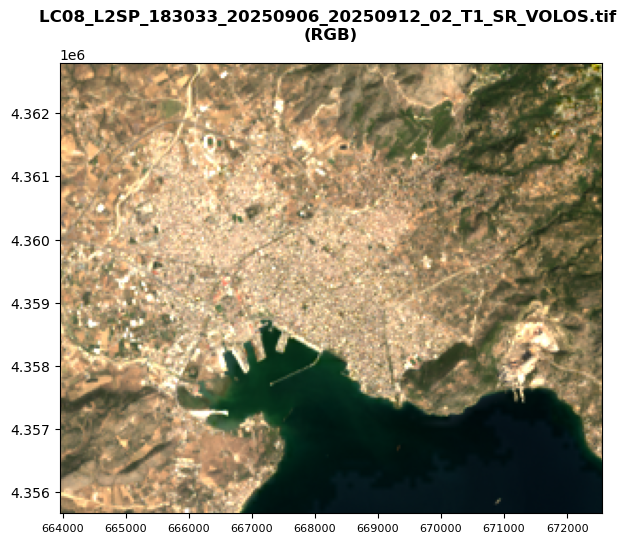

In [10]:
def percentile_stretch(img, p_min=2, p_max=98):
    # υπολογισμός τεταρτημορίων (percentiles)
    low, high = np.percentile(img, (p_min, p_max))
    
    # Stretch και αποκοπή
    stretched = (img - low) / (high - low)
    return np.clip(stretched, 0, 1)


# Ανάγνωση εικόνας και πιο συγκεκριμένα τις μπάντε με ευρετήρια 4,3,2
with rasterio.open(path) as src:
    rgb =src.read([4, 3, 2])
    transform = src.transform

# Rescale rgb με την μέθοδο percentile stretch
rescaled_visual = percentile_stretch(rgb)

# Δημιουργία figure και axes
fig, ax = plt.subplots(figsize=(7, 7))

# Οπτικοποίηση μέσω show της rasterio
show(rescaled_visual ,title=f'{path} \n(RGB)', transform=transform, ax=ax)


# ορισμός x-axis tick interval σε 5000
ax.xaxis.set_major_locator(MultipleLocator(1000))

# ορισμός font size και rotation στα x-axis labels
plt.xticks(rotation=0, fontsize = 8)

plt.show()


## Δημιουργία ιστογράμματος συχνοτήτων

Η `rasterio` δίνει την δυνατότητα δημιουργίας ιστογράμματος συχνοτήτων των τιμών των εικονοστοιχείων μιας εικόνας με την συνάρτηση `show_hist`.

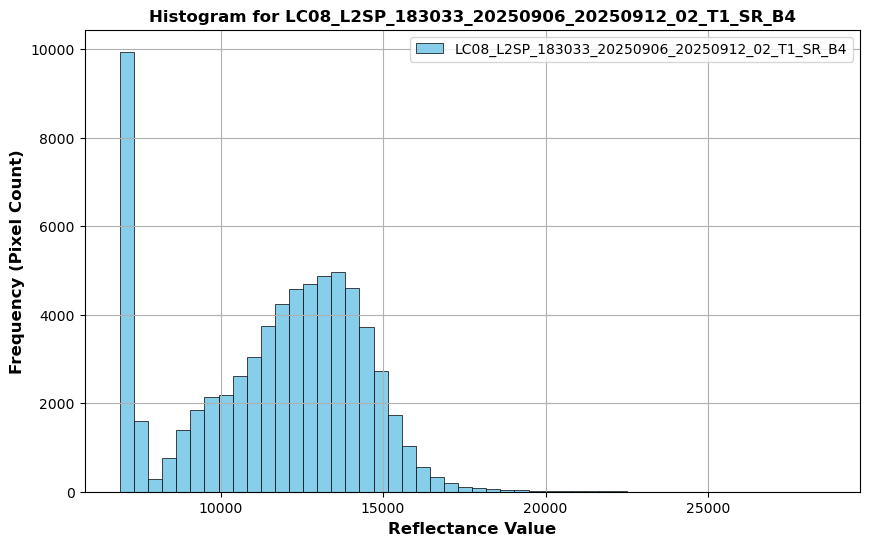

In [11]:
band_id = 'LC08_L2SP_183033_20250906_20250912_02_T1_SR_B4'


fig, axhist = plt.subplots(1, 1, figsize=(10, 6))

# Δημιουργία ιστογράμματος συχνοτήτων
show_hist(bands[band_id], 
          ax=axhist, 
          bins=50, 
          facecolor='skyblue',  # Fill color
          edgecolor='black', # Outline color
          lw=0.5,              # Outline thickness (must be > 0)
          #histtype='stepfilled', 
          title=f"Histogram for {band_id}",
          label=f"{band_id}") # Set your legend text here

# Ορισμός του X και Y axis labels

axhist.set_xlabel("Reflectance Value", fontsize=12, fontweight='bold')
axhist.set_ylabel("Frequency (Pixel Count)", fontsize=12, fontweight='bold')

# Κλήση της legend() για να εμφανιστεί του υπόμνημα στο πάνω δεξιά τμήμα του γραφήματος
axhist.legend(loc='upper right', fontsize=10)
plt.show()

## Ανάγνωση μεταδεδομένων

Όπως αναφέρθηκε κατά την ανάγνωση είναι δυνατόν να αγνοηθεί το index του καναλιού και κατά συνέπεια να αναγνωστούν όλα τα κανάλια της εικόνας.

Από ένα ανοικτό αρχείο μέσω του `rasterio` μπορούμε να ανακτήσουμε χρήσιμες ιδιότητες για το raster. Για παράδειγμα μπορούμε να ανακτήσουμε το προβολικό σύστημα, τις διαστάσεις (width, height) του σε pixels, το bounding box και τον αριθμό των καναλιών. Επίσης, στην `rasterio`, το `meta` (ή `profile`) είναι ένα λεξικό μεταδεδομένων που περιγράφει διάφορες ιδιότητες για το raster αρχείο. Η ιδιότητα `profile` παρέχει πιο πολλές λεπτομέρειες αναφορικά με τις ιδιότητες του αρχείου.



In [12]:
with rasterio.open(url) as ds:
    window = from_bounds(
        left=left,
        bottom=bottom,
        right=right,
        top=top,
        transform=ds.transform
    )
    data_all_bands = ds.read(window=window) # ανάγνωση όλων των καναλιών και σε γεωγραφικό υποσύνολο της εικόνας# Print
    
    print(f"CRS: {ds.crs}")
    print(f"Shape (rows, cols): ({ds.height}, {ds.width})")
    print(f"Bounds: {ds.bounds}")
    print(f"Number of bands: {ds.count}")
    print(f"Cell resolution (x, y): {ds.res}")
    print('-'*50)
    print(ds.meta)
    print('-'*50)
    print(ds.profile)

CRS: EPSG:32634
Shape (rows, cols): (7731, 7601)
Bounds: BoundingBox(left=608385.0, bottom=4192785.0, right=836415.0, top=4424715.0)
Number of bands: 7
Cell resolution (x, y): (30.0, 30.0)
--------------------------------------------------
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7601, 'height': 7731, 'count': 7, 'crs': CRS.from_epsg(32634), 'transform': Affine(30.0, 0.0, 608385.0,
       0.0, -30.0, 4424715.0)}
--------------------------------------------------
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7601, 'height': 7731, 'count': 7, 'crs': CRS.from_epsg(32634), 'transform': Affine(30.0, 0.0, 608385.0,
       0.0, -30.0, 4424715.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}


## Αλλαγή προβολικού συστήματος

Η βιβλιοθήκη rasterio δίνει την δυνατότητα μετατροπής του προβολικού συστήματος ενός αρχείου σε ένα άλλο (reprojection).
Αν και δεν είναι ιδιαίτερα εύχρηστη ως προς την διαδικασία σε σχέση με άλλες βιβλιοθήκες ή λογισμικά ωστόσο δίνει μεγάλη ευλιξία στον χρήστη.

In [13]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Paths
src_path = 'LC08_L2SP_183033_20250906_20250912_02_T1_SR_VOLOS.tif'     # αρχική είκονα Landsat 8 multiband σε EPSG:32634 - WGS 84 / UTM zone 34N

dst_path = "Volos_2100.tif" # όνομα εξαγώγιμου αρχείου 

# Προβολικό σύστημα (CRS) εξαγώγιμου αρχείου: ΕΓΣΑ '87 (Greek Grid)
dst_crs = "EPSG:2100"
target_res = 30  # ανάλυση στο νέο προβολικό σύστημα (Greek Grid)

with rasterio.open(src_path) as src:
    # ανάγνωση metadata και δημιουργία αντιγράφου
    meta = src.meta.copy()

    # Υπολογισμό transform, width, height για το CRS στόχο
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=target_res
    )


    # Ανάγνωση nodata τιμής από το αρχείο προέλευσης
    src_nodata = src.nodata
    
    # Αν δεν υπάρχει src_nodata τότε όρισε την maximum τιμή του συγκεκριμένου datatype
    if src_nodata is None:
        dtype = np.dtype(src.meta['dtype'])
        if np.issubdtype(dtype, np.integer):
            src_nodata = np.iinfo(dtype).max
        else:
            # For float types, use np.finfo
            src_nodata = np.finfo(dtype).max
            
            
    # numpy array υποδοχής των reprojected pixels με Nans (ίδιο πλήθος καναλιών, bands)
    dst_array = np.full((src.count, height, width), src_nodata, dtype=src.meta['dtype'])

    # Reproject για κάθε κανάλι του αρχικού raster
    for i in range(1, src.count + 1):
        reproject(
            source=rasterio.band(src, i),
            destination=dst_array[i - 1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear  # ή 'nearest' αν τα δεδομένα το αρχικού raster είναι κατηγορικά
        )

    # Ενημέρωση metadata με βάση τις ιδιότητες του CRS
    meta.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height,
        'nodata': src_nodata,
        'dtype': src.meta['dtype'],
        "compress": "lzw"
    })


# Αποθήκευση σαν geotiff του νέου αρχείου
with rasterio.open(dst_path, 'w', **meta) as dst:
    dst.write(dst_array)

print(f"Data export:{dst_path}\n\
(nodata value:{src_nodata},\
datatype:{src.meta['dtype']},\
CRS:{dst_crs},\
resolution:{target_res})")


Data export:Volos_2100.tif
(nodata value:0.0,datatype:uint16,CRS:EPSG:2100,resolution:30)


## Αποκοπή εικόνας με βάση διανυσματικά δεδομένα  (πχ με Shapely/GeoPandas integration) 


Επιπλέον υπάρχει η λειτουργία της αποκοπής (crop) και κάλυψη (mask) μιας εικόνας με βάση ένα διανυσματικό αρχείο. Στο παρακάτω παράδειγμα η εικόνα LandSat αποκόπτεται και γίνεται mask στα όρια του Δήμου Βόλου.

In [14]:
from rasterio.mask import mask
import geopandas as gpd

# Ορισμός path των αρχείων
vector_path = "data/OTA/0adb0521-2223-43cd-96d3-d816ad7a193c.shp"
output_path = "LandSat8_Volos_clipped.tif"

# Ανάγνωση διανυσματικών δεδομένων με GeoPandas
gdf = gpd.read_file(vector_path)
gdf = gdf[gdf['NAME_LATIN']=='D. BOLOY']


# Άνοιγμα τμήματος αρχείου μέσω του rasterio και της συνάρτησης om_bounds
# These settings are for cloud performance
env_options = {
    'GDAL_HTTP_MERGE_CONSECUTIVE_REPORTS': 'YES',
    'GDAL_HTTP_MULTIPLEX': 'YES',
    'GDAL_HTTP_VERSION': '2',
    'VSI_CACHE': 'YES',
    'VSI_CACHE_SIZE': '50000000', # 50MB cache
    'GDAL_DISABLE_READDIR_ON_OPEN': 'EMPTY_COLUMN',
}

with rasterio.Env(**env_options):
        
    with rasterio.open(url) as src:
        window = from_bounds(
            left=left,
            bottom=bottom,
            right=right,
            top=top,
            transform=ds.transform
        )
    
        # Έλεγχος αν τα προβολικά συστήματα της εικόνας και του διανυσματικού αρχείου geopandas dataframe ειναι ίδια  
        if gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)
    
        # Μετατροπή των geometries σε GeoJSON dictionaries
        geoms = gdf.geometry.values  # Shapely geometries
        geoms = [geom.__geo_interface__ for geom in geoms] #Μετατροπή των Shapely geometries σε GeoJSON dictionaries
    
        # Αποκοπή και mask του raster αρχείου
        out_image, out_transform = mask(src, geoms, crop=True)
    
        # Update metadata for output
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": src.nodata
        })

# Εγγραφή του clipped raster αρχείου
with rasterio.open(output_path, "w", **out_meta) as dst:
    dst.write(out_image)



## Resample

Σε αρκετές περιπτώσεις, είτε για λόγους γενίκευσης της πληροφορίας, είτε για λόγους σύγκρισης και ανάλυσης ταυτόχρονα με άλλα raster αρχεία, είναι απαραίτητος ο μετασχηματισμός της χωρικής ανάλυσης ενός ψηφιδωτού αρχείου (resampling). 

Με τον όρο `resampling` εννοείται η διαδικασία κατά την οποία αλλάζει η χωρική ανάλυση (spatial resolution) ενός ψηφιδωτού αρχείου διατηρώντας την αρχική γεωγραφική έκταση που αυτό καλύπτει.

Έτσι η διαδικασία αυτή μπορεί είτε να μεγαλώσει τις διαστάσεις του κάθε pixel (downsampling) και κατα συνέπεια η ίδια περιοχή να καλύπτεται από λιγότερα pixels σε σχέση με τις αρχικές διαστάσεις. Είτε η αντίστροφη διαδικασία, δηλαδή να μικραίνουν οι διαστάσεις των pixel (upsampling) και έτσι η αρχική έκταση του αρχείου να καλύπτεται από περισσότερα pixels. 


In [15]:
from rasterio.enums import Resampling
from rasterio.transform import from_origin
import math

# paths
src_path = "Volos_2100.tif" # το αρχείο αυτό έχει ανάλυση 30m.
dst_path = "Volos_2100_100m.tif"

# ορισμός νέας διάσταση των pixel (target resolution)
target_res = 100  # ανάλυση pixel: 100 μέτρα

with rasterio.open(src_path) as src:
    # Υπολογισμός του width και height με βάση την νέα διάσταση των pixel που θέλουμε
    width = math.ceil((src.bounds.right - src.bounds.left) / target_res)
    height = math.ceil((src.bounds.top - src.bounds.bottom) / target_res)

    # Δημιουργία νέου  affine transform object
    # https://rasterio.readthedocs.io/en/latest/api/rasterio.transform.html#rasterio.transform.from_origin
    # Ορισμός του top left pixel και την χωρική ανάλυση του κάθε pixel (cell resolution)
    transform = from_origin(src.bounds.left, src.bounds.top, target_res, target_res) # west, north, xsize, ysize

    # ανάγνωση αρχείου, ορισμός resampling μεθόδου
    # data_resampled που θα προκύψει με το νέο resolution είναι ένα numPy array
    data_resampled = src.read(
        out_shape=(src.count, height, width),
        resampling=Resampling.bilinear  # 'nearest' για κατηγορικά (categorical) δεδομένα
    )

    # για την αποθήκευηση σε geotiff πρέπει να ορίσουμε τα metadata με τις νέες ιδιότητες
    kwargs = src.meta.copy()
    kwargs.update({
        "height": height,       # νέο height με βάση το νέο resolution
        "width": width,         # νέο width με βάση το νέο resolution
        "transform": transform, # το νέο transform object που υπολογίσττηκε παραπάνω
        "nodata": src.nodata,   # τιμή nodata ίδια με τον αρχικό raster
        "compress": "lzw",      # LZW compression
    })

# 5. Αποθήκευση ως geotigg resampled raster
with rasterio.open(dst_path, "w", **kwargs) as dst:
    dst.write(data_resampled)

print(f"Done: Raster resampled to {target_res}m and saved as {dst_path}")



Done: Raster resampled to 100m and saved as Volos_2100_100m.tif



## NDVI

Μέσω της ανάγνωσης ψηφιδωτών αρχείων και της μετατροπής τους σε numpy array είναι εφικτή η άλγεβρα χαρτών και ο υπολογισμός δεικτών. Το επόμενο τμήμα κώδικα αφορά την δημιουργία του δείκτη πρασίνου [NDVI (Normalized Difference Vegetation Index)](https://en.wikipedia.org/wiki/Normalized_difference_vegetation_index) με βάση μια δορυφορική εικόνα [Landsat 8 Collection 2 Surface Reflectance](https://www.usgs.gov/landsat-missions/landsat-collection-2-surface-reflectance). Τα απαραίτητα κανάλια για την δημιουργία δείκτη NDVI είναι το κοντινό υπέρυθρο (near-infrared) το ερυθρό (red), κανάλια 5 και 4 αντίστοιχα για τον Landsat 8.

In [16]:
# Paths
input_path = "Volos_2100.tif"
ndvi_path = 'Landsat_NDVI.tif'

# Landsat 8 κανάλια για τον υπολογισμό του NDVI
# B4 = Red (Band 4), B5 = NIR (Band 5) 1-based index στην ρasterio
RED_BAND = 4
NIR_BAND = 5

# Συνάρτηση για την εφαρμογή Scale factor
# https://www.usgs.gov/faqs/how-do-i-use-a-scale-factor-landsat-level-2-science-products
def apply_sr(dn):
    return dn * 0.0000275 - 0.2

# Ανάγνωση multiband εικόνας
with rasterio.open(input_path) as src:
    # αντίγραφο του meta object, απαραίτητο στην συνέχεια κατά την δημιουργία του νεου NDVI αρχείου
    meta = src.meta.copy()
    
    # ανάγνωση RED και NIR καναλιών και μετατροπή σε float32 (δεκαδικό τύπο δεδομένων ακρίβειας 32 bit)
    red = src.read(RED_BAND).astype(np.float32)
    nir = src.read(NIR_BAND).astype(np.float32)
    
    # Εφαρμογή scale factor ώστε να μετατραπεί το DN σε reflectance values
    red_sr = apply_sr(red)
    nir_sr = apply_sr(nir)

   
    # Επιβάλλουμε στην numpy να αγνοήσει σφάλματα διαίρεσης με το 0
    np.seterr(divide='ignore', invalid='ignore')

    # Υπολογισμός δείκτη NDVI
    # Η διαίρεση με το 0 στην παρακάτω πράξη θα αποδόσει τιμές Nan
    ndvi = (nir - red) / (nir + red)

    
    # ενημέρωση των metadata με βάση τον νέο τύπο δεδομένων (dtype) float32 και το πλήθος των καναλιών (count)
    meta.update({
        "driver": "GTiff",
        "dtype": "float32", # NDVI έχει δεκαδικές τιμές, οπότε αλλάζουμε το dtype σε float32
        "count": 1,         # Έχουμε ένα μόνο κανάλι, το NDVI
        "nodata": -9999     # ορισμός τιμής για τα pixel με nodata
    })
    


    # Ορισμός των pixel με τιμή Nan σε -9999
    ndvi[np.isnan(ndvi)] = -9999
    
    # Εγγραφή του numpy array με το NDVI σε νέο αρχειο geotif
    with rasterio.open(ndvi_path, 'w', **meta) as dst:
        dst.set_band_description(1, 'NDVI') # περιγραφή του καναλιού στο εξαγόμενο αρχείο
        dst.write(ndvi, 1) 
        
        
    print(f"Το αρχείο NDVI αποθηκεύτηκε στο {ndvi_path}")



Το αρχείο NDVI αποθηκεύτηκε στο Landsat_NDVI.tif


Ακολουθεί συνοπτική οπτικοποιήση του αποτελέσματος μέσω το `matplotlib` 

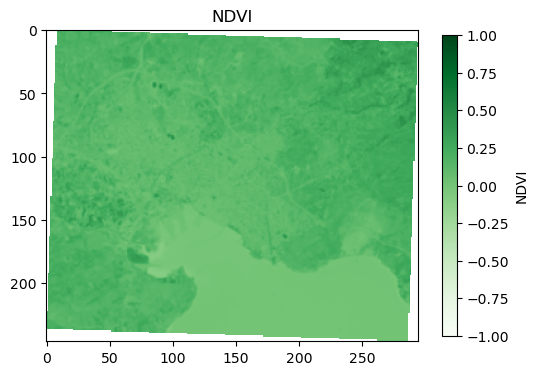

In [17]:
# απόκρυψη (mask) pixel που έχουν την τιμή -9999 (flagged as nodata)
ma_ndvi= np.ma.masked_equal(ndvi, -9999)

# Οπτικοποίηση του NDVI
plt.figure(figsize=(6, 6))
img = plt.imshow(ma_ndvi,
                 vmin=-1,
                 vmax=1, 
                 cmap='Greens')

plt.colorbar(img, label='NDVI', shrink=0.65) # υπόμνημα
plt.title("NDVI")
plt.xlabel("")
plt.ylabel("")
plt.show()


## Πηγές δεδομένων

- Earth Resources Observation and Science (EROS) Center. (2020). Landsat 8-9 Operational Land Imager / Thermal Infrared Sensor Level-2, Collection 2 [dataset]. U.S. Geological Survey. https://doi.org/10.5066/P9OGBGM6 